# 06 - Small data: full conformal, jackknife+ and CV+

> "We have 120 sales on the books. And your plan is to throw away a third of them on
> 'calibration'?" — head of the Marlow Bay acquisitions desk, week one

Hearthstone is expanding into Marlow Bay, a small coastal market where the public records
show exactly 120 sold listings. The desk wants price intervals like the ones we built for
Riverton in notebook 02 — but that recipe assumed data to spare: fit the model on one part,
calibrate the threshold on the rest. With 120 sales, an 80/40 split starves the model *and*
gambles the guarantee on 40 calibration scores — notebook 03 called realized coverage a
lottery ticket, and 40 points buys a terrible one.

The sharper statistical question: **can we keep the finite-sample coverage guarantee while
letting every one of the 120 sales do double duty — inform the model fit and set the
threshold — and what does that cost?** The answer is yes, three different ways, and the cost
is always the same currency: compute.

What you will learn:

- how to measure what the split actually costs at n = 120 — a noisy coverage lottery and
  wide intervals, both quantified
- full conformal prediction: the original no-split method, where every candidate price
  auditions inside the model
- why the obvious leave-one-out shortcut (the naive jackknife) has no guarantee, and how
  jackknife+ repairs it while barely changing the code
- CV+: jackknife+ at a tenth of the compute — the version you can afford with gradient
  boosting
- how to choose between split, full, jackknife+ and CV+ from data size and compute budget

Where we are in the series: notebook 05 made interval *widths* adapt to each home; this
notebook makes the *guarantee* affordable when homes are scarce; notebook 07 asks what
happens when the market itself shifts under you.

One warning before we start: this is the most technical notebook so far. It earns that
label with exactly three ideas, and each one is simple — refit with the candidate
included, leave one out, leave a fold out. Everything else is bookkeeping.

In [1]:
import math
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import KFold

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
RANDOM_SEED = 20260707

BLUE, GREEN, AMBER, RED, GRAY, PURPLE = (
    "#2563EB", "#059669", "#F59E0B", "#DC2626", "#6B7280", "#7C3AED",
)

alpha = 0.10        # miscoverage budget: we target 90% coverage throughout the series
RIDGE_LAMBDA = 1.0  # ridge PENALTY strength - sklearn calls it `alpha`, an unfortunate
                    # naming collision with our miscoverage rate; they are unrelated

## 1. The cost of the split

Marlow Bay's 120 sales come from the same simulator every Hearthstone notebook uses —
reproduced verbatim below, docstring and all, because the docstring is the data
documentation. Because we simulate, we can also mint a 2,000-home test pool to measure
coverage honestly. The desk does not have that luxury; that is exactly why they need a
guarantee instead of a backtest.

The plan for this section: run notebook 02's fifteen-line split recipe on Marlow Bay, then
run it again on 199 other random 80/40 splits of the *same* 120 sales, and look at the
distribution of what the desk would have shipped. One split is one lottery ticket (field
guide §4); with 200 tickets we can see the whole lottery.

In [2]:
FEATURE_NAMES = ["size_m2", "age_years", "dist_center_km", "condition_1to5"]

def simulate_hearthstone_listings(n, seed, region="riverton"):
    """Simulate n home listings for Hearthstone, our property-tech startup.

    What the simulator bakes in (and what we will test against later):
    - Price depends nonlinearly on size, age, distance to the center, and condition.
    - Noise is larger for bigger homes: two 60 m2 flats sell for nearly the same
      price, two 300 m2 villas do not. This heteroskedasticity is deliberate.
    - 'riverton' and 'eastvale' differ ONLY in the mix of homes on the market
      (newer, bigger, farther out in eastvale), NOT in how features map to price.
      In the language of notebook 07: pure covariate shift, identical P(price | features).

    Returns X (n x 4 array: size_m2, age_years, dist_center_km, condition_1to5)
    and y (price in thousands of dollars).
    """
    rng = np.random.default_rng(seed)
    if region == "riverton":
        size = rng.gamma(shape=6.0, scale=20.0, size=n) + 30.0
        age = rng.uniform(0.0, 60.0, size=n)
        dist = rng.exponential(scale=6.0, size=n)
    elif region == "eastvale":
        size = rng.gamma(shape=9.0, scale=24.0, size=n) + 40.0
        age = rng.uniform(0.0, 25.0, size=n)
        dist = rng.exponential(scale=12.0, size=n)
    else:
        raise ValueError(f"Unknown region: {region}")
    condition = rng.integers(1, 6, size=n).astype(float)
    log_price = (
        10.0
        + 0.70 * np.log(size)
        - 0.004 * age
        - 0.035 * dist
        + 0.05 * condition
    )
    noise_sd = 0.10 + 0.0008 * size  # bigger homes, noisier prices - on purpose
    log_price = log_price + rng.normal(0.0, noise_sd)
    X = np.column_stack([size, age, dist, condition])
    return X, np.exp(log_price) / 1000.0

# Marlow Bay is a new market in the story, but statistically we reuse the standard
# 'riverton' generator - the story names the market, the generator stays identical.
X_mb, y_mb = simulate_hearthstone_listings(120, seed=RANDOM_SEED)
X_pool, y_pool = simulate_hearthstone_listings(2000, seed=RANDOM_SEED + 1)

print(f"Marlow Bay books   : {len(y_mb)} sold listings, "
      f"prices ${y_mb.min():.0f}k to ${y_mb.max():.0f}k, median ${np.median(y_mb):.0f}k")
print(f"Fresh test pool    : {len(y_pool)} listings (simulation luxury - the desk has 120)")

Marlow Bay books   : 120 sold listings, prices $144k to $1566k, median $646k
Fresh test pool    : 2000 listings (simulation luxury - the desk has 120)


Median price around $646k with a long right tail — the usual Hearthstone mix of flats and
villas, just far fewer of them. Now the lottery. Each repetition below is exactly notebook
02: fit the desk's standard `GradientBoostingRegressor` on 80 sales, compute absolute
residuals — our usual nonconformity score — on the 40 held-out sales, take the corrected
quantile, and check the resulting intervals against the 2,000-home pool. The only thing
that changes between repetitions is which 80 sales the model gets.

One number to watch before we run it: with 40 calibration scores, the corrected rank
`ceil((40 + 1) * 0.9) = 37` is safely below 40, so the interval is at least finite. At
alpha = 0.10 you need roughly 10 calibration points before the honest answer stops being
"the entire real line" (field guide §1); 40 clears that bar, but not by much.

split conformal at n=120, 200 random 80/40 splits, target coverage 0.90:
  coverage: mean 0.928, sd 0.036, min 0.798, max 0.990
  tickets below 0.85: 4.0%   tickets above 0.95: 32.5%
  interval width: mean $775k, min $493k, max $1198k (widest/narrowest = 2.4x)


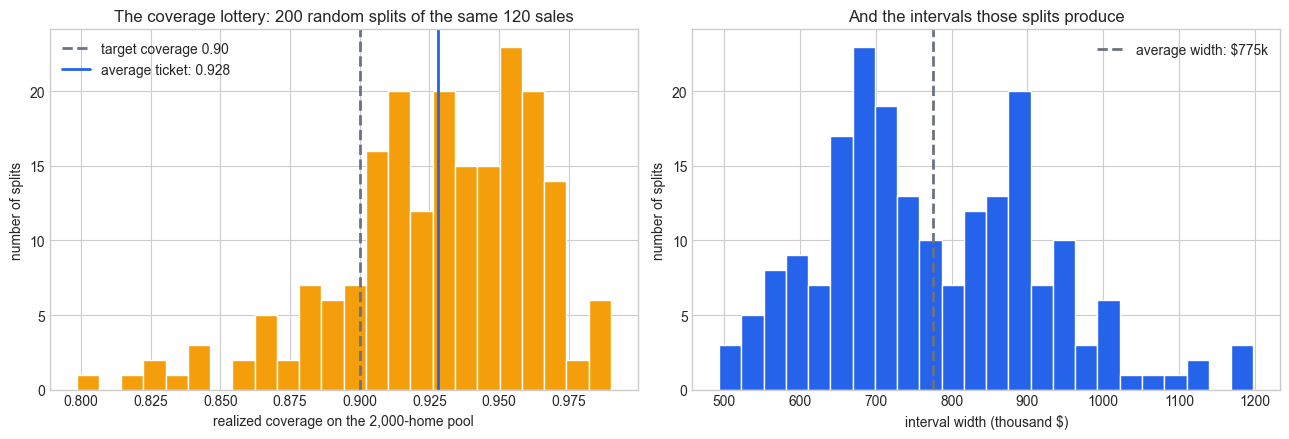

In [3]:
n_cal = 40
assert math.ceil((n_cal + 1) * (1 - alpha)) <= n_cal, (
    "Calibration set too small for this alpha - the honest interval is infinite "
    "(field guide S1)"
)

R = 200
rng_splits = np.random.default_rng(RANDOM_SEED)
split_coverages = np.empty(R)
split_widths = np.empty(R)

for r in range(R):
    # a fresh random 80/40 split of the SAME 120 sales - a new lottery ticket
    perm = rng_splits.permutation(120)
    train_idx, cal_idx = perm[:80], perm[80:]

    model = GradientBoostingRegressor(random_state=RANDOM_SEED)
    model.fit(X_mb[train_idx], y_mb[train_idx])

    scores = np.abs(y_mb[cal_idx] - model.predict(X_mb[cal_idx]))
    n = len(scores)
    q_level = math.ceil((n + 1) * (1 - alpha)) / n
    q_hat = np.quantile(scores, q_level, method="higher")

    pred_pool = model.predict(X_pool)
    covered = (y_pool >= pred_pool - q_hat) & (y_pool <= pred_pool + q_hat)
    split_coverages[r] = covered.mean()
    split_widths[r] = 2 * q_hat

print(f"split conformal at n=120, {R} random 80/40 splits, target coverage 0.90:")
print(f"  coverage: mean {split_coverages.mean():.3f}, sd {split_coverages.std():.3f}, "
      f"min {split_coverages.min():.3f}, max {split_coverages.max():.3f}")
print(f"  tickets below 0.85: {np.mean(split_coverages < 0.85):.1%}   "
      f"tickets above 0.95: {np.mean(split_coverages > 0.95):.1%}")
print(f"  interval width: mean ${split_widths.mean():.0f}k, "
      f"min ${split_widths.min():.0f}k, max ${split_widths.max():.0f}k "
      f"(widest/narrowest = {split_widths.max() / split_widths.min():.1f}x)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(split_coverages, bins=24, color=AMBER, edgecolor="white")
axes[0].axvline(0.90, color=GRAY, ls="--", lw=2, label="target coverage 0.90")
axes[0].axvline(split_coverages.mean(), color=BLUE, lw=2,
                label=f"average ticket: {split_coverages.mean():.3f}")
axes[0].set_title("The coverage lottery: 200 random splits of the same 120 sales")
axes[0].set_xlabel("realized coverage on the 2,000-home pool")
axes[0].set_ylabel("number of splits")
axes[0].legend()
axes[1].hist(split_widths, bins=24, color=BLUE, edgecolor="white")
axes[1].axvline(split_widths.mean(), color=GRAY, ls="--", lw=2,
                label=f"average width: ${split_widths.mean():.0f}k")
axes[1].set_title("And the intervals those splits produce")
axes[1].set_xlabel("interval width (thousand $)")
axes[1].set_ylabel("number of splits")
axes[1].legend()
plt.tight_layout()
plt.show()

Read the left panel first. The average ticket lands at 0.928 — *above* the 0.90 target,
and that is not a bug. With 40 scores the achievable coverage levels come in coarse steps
of about 1/41 = 2.4 points, and the corrected quantile must round up to stay honest: on a
40-score grid, `method="higher"` lands on the 38th smallest score, and theory then predicts
an average coverage of 38/41 = 0.927. Our 0.928 is dead on it. The overshoot is not a
gift; it is paid for in width.

Now the spread: individual tickets range from 0.798 to 0.990, 4.0% of them cover less
than 0.85, and roughly a third sit above 0.95. Whichever single split the desk happened to
pick, that is the ticket they would have shipped — and they would never know which one they
got, because in production there is no 2,000-home pool to check against.

The right panel is the second half of the bill: intervals average $775k wide, and the
widest ticket ($1198k) is 2.4 times the narrowest ($493k). Both halves of the split are
starving at once — the model sees only 80 sales, so its residuals are large; the threshold
sees only 40 scores, so it is noisy *and* systematically rounded up.

One caution about what this does **not** mean: the lottery does not break the guarantee.
Averaged over splits, coverage is at or above 90%, exactly as promised — the promise was
always marginal (notebook 03). The problem is that at n = 120 the *variance* around that
promise is enormous. To fix it we need methods that let all 120 sales do double duty.

## 2. Idea 1: full conformal — every candidate answers for itself

**Full conformal prediction** is the original 1990s form of the method, invented by Vovk,
Gammerman and colleagues — notebook 02's split recipe is historically the industrial
shortcut. It removes the calibration set with one strange, beautiful move: *audition every
candidate answer inside the model*.

For a new house $x_{\text{new}}$ and a candidate price $y$:

1. Temporarily add the pair $(x_{\text{new}}, y)$ to the 120 real sales, as if it were a
   121st sale.
2. **Refit the model** on all 121 points.
3. Compute all 121 absolute residuals under that refit.
4. Ask: does the trial pair stick out? The **conformal p-value** of the candidate is the
   fraction of the 121 residuals that are at least as large as the trial pair's own
   residual. In symbols:

$$p(y) = \frac{\#\{\, i \in \{1,\dots,n{+}1\} : r_i^{(y)} \ge r_{\text{trial}}^{(y)} \,\}}{n+1}$$

where $r_i^{(y)}$ is sale $i$'s residual under the refit-with-the-trial-pair model,
$r_{\text{trial}}^{(y)}$ is the trial pair's own residual, and $n+1 = 121$. A price that
fits in has an unremarkable residual and a large p-value; a ridiculous price drags the fit
toward itself, still sticks out, and gets a small one.

5. Keep every candidate with $p(y) > \alpha$. The kept candidates *are* the prediction
   interval — "keep all the values you cannot reject". (This is the same
   `ceil((n+1)(1-alpha))` rank rule from notebook 02 wearing different clothes: p-value
   above alpha is exactly "residual rank low enough".)

Why is this valid? If the candidate happens to be the *true* price, then the trial pair is
just another exchangeable member of the bag of 121, so its residual is equally likely to
hold any rank — notebook 03's leaderboard argument, verbatim. The one new requirement:
because the test point competes *inside* the training set, the fitting algorithm must be
**symmetric** — it must not care about the order of its training points. Ridge is; so is
gradient boosting; non-shuffled SGD or early stopping keyed to "the last rows" is not.

The price is compute: one refit per candidate per house. Tibshirani's lecture notes animate
this — as the trial $y$ slides upward, you watch the refit curve get pulled up with it. We
use ridge regression, which refits in microseconds, and audition 161 candidate prices in
$10k steps around a first-guess price. Here is one house's audition.

house 0: 126 m2, 26 years old, 18.3 km from center, condition 4
  auditioned 161 candidate prices, kept 53 -> interval [$181k, $701k], width $520k
  actual sale price: $305k


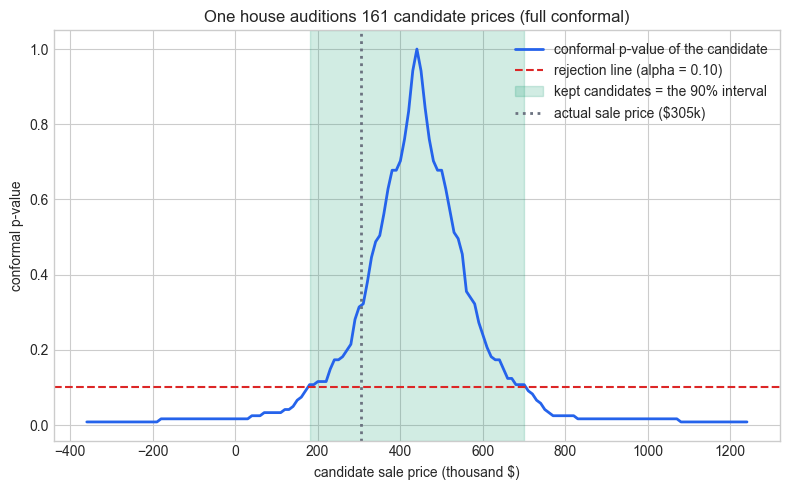

In [4]:
def full_conformal_pvalues(X_train, y_train, x_new, y_grid):
    """Audition every candidate price in y_grid for the house x_new.

    For each candidate y: refit ridge on the n real sales PLUS the trial pair
    (x_new, y), then return the conformal p-value - the fraction of the n+1
    augmented residuals at least as large as the trial pair's own. The trial
    pair counts itself, so p >= 1/(n+1): even the worst candidate is never
    impossible, merely rejected at level alpha.
    """
    n = len(y_train)
    X_aug = np.vstack([X_train, x_new])
    pvals = np.empty(len(y_grid))
    for j, y_cand in enumerate(y_grid):
        y_aug = np.append(y_train, y_cand)
        refit = Ridge(alpha=RIDGE_LAMBDA).fit(X_aug, y_aug)   # ridge penalty, not miscoverage
        resid = np.abs(y_aug - refit.predict(X_aug))
        pvals[j] = np.mean(resid >= resid[-1])                # trial pair sits at index -1
    return pvals

# the model whose point prediction centers each house's candidate grid
ridge_all = Ridge(alpha=RIDGE_LAMBDA).fit(X_mb, y_mb)

house = 0  # first home in the fresh pool
center = ridge_all.predict(X_pool[house:house + 1])[0]
y_grid = np.linspace(center - 800, center + 800, 161)  # +/- $800k in $10k steps
p_values = full_conformal_pvalues(X_mb, y_mb, X_pool[house], y_grid)

keep = p_values > alpha
assert keep.any(), "empty prediction set - something is wrong with the grid or the score"
assert not (keep[0] or keep[-1]), "kept set touches the grid edge - widen the grid"
lo, hi = y_grid[keep].min(), y_grid[keep].max()

print(f"house {house}: {X_pool[house, 0]:.0f} m2, {X_pool[house, 1]:.0f} years old, "
      f"{X_pool[house, 2]:.1f} km from center, condition {X_pool[house, 3]:.0f}")
print(f"  auditioned {len(y_grid)} candidate prices, kept {keep.sum()} "
      f"-> interval [${lo:.0f}k, ${hi:.0f}k], width ${hi - lo:.0f}k")
print(f"  actual sale price: ${y_pool[house]:.0f}k")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(y_grid, p_values, color=BLUE, lw=2, label="conformal p-value of the candidate")
ax.axhline(alpha, color=RED, ls="--", lw=1.5, label="rejection line (alpha = 0.10)")
ax.axvspan(lo, hi, color=GREEN, alpha=0.18, label="kept candidates = the 90% interval")
ax.axvline(y_pool[house], color=GRAY, ls=":", lw=2,
           label=f"actual sale price (${y_pool[house]:.0f}k)")
ax.set_title("One house auditions 161 candidate prices (full conformal)")
ax.set_xlabel("candidate sale price (thousand $)")
ax.set_ylabel("conformal p-value")
ax.legend()
plt.tight_layout()
plt.show()

The curve is the whole method in one picture. Near the model's own opinion the p-value
climbs to 1.0 — those candidates, once added, look like perfectly ordinary sales. Walk away
from the center and the trial pair sticks out more and more, even though every refit pulls
the model toward it. Where the curve drops below the red line at 0.10, candidates get
rejected; what survives is the green band, [$181k, $701k]. The actual sale price, $305k,
sits comfortably inside.

Note the shape of the claim: this is a confidence set built by inverting a permutation-style
test — 1930s rank statistics doing 2020s uncertainty quantification. And note what the
curve's peak does **not** mean: p = 1.0 is not "this price has probability 1" or even "this
is the most probable price". Conformal p-values measure *conformity with the data*, not
posterior probability; the peak just marks the candidates the data cannot begin to object to.

One house is a demo, not evidence. Let us price the first 30 houses in the pool and check
coverage and width for real.

In [5]:
n_test_fc = 30
fc_lo, fc_hi = np.empty(n_test_fc), np.empty(n_test_fc)

for i in range(n_test_fc):
    center = ridge_all.predict(X_pool[i:i + 1])[0]
    grid_i = np.linspace(center - 800, center + 800, 161)
    p_i = full_conformal_pvalues(X_mb, y_mb, X_pool[i], grid_i)
    keep_i = p_i > alpha
    assert not (keep_i[0] or keep_i[-1]), f"grid edge hit at house {i} - widen the grid"
    fc_lo[i], fc_hi[i] = grid_i[keep_i].min(), grid_i[keep_i].max()

fc_covered = (y_pool[:n_test_fc] >= fc_lo) & (y_pool[:n_test_fc] <= fc_hi)
print(f"full conformal on 30 fresh houses: covered {fc_covered.sum()}/30 "
      f"({fc_covered.mean():.3f}), mean width ${np.mean(fc_hi - fc_lo):.0f}k")
print(f"(split conformal averaged ${split_widths.mean():.0f}k wide in section 1)")

first5 = pd.DataFrame({
    "true_price_k": y_pool[:5],
    "interval_lo_k": fc_lo[:5],
    "interval_hi_k": fc_hi[:5],
    "covered": fc_covered[:5],
})
first5.round(1)

full conformal on 30 fresh houses: covered 27/30 (0.900), mean width $520k
(split conformal averaged $775k wide in section 1)


,true_price_k,interval_lo_k,interval_hi_k,covered
0,305.5,180.6,700.6,True
1,385.1,232.4,752.4,True
2,693.9,340.1,850.1,True
3,219.3,-230.6,319.4,True
4,486.5,398.3,908.3,True


Coverage lands at 27/30 = 0.900 — although with only 30 test houses, anywhere from 25 to
29 would have been consistent with a working 90% method, so treat the exact hit as a
pleasant coincidence, not a diploma. The number that is *not* a coincidence: mean width
$520k, against the split's $775k average — a third narrower at the same n = 120, with the
same guarantee. Nothing was free: all 120 sales inform the fit *and* all 121 residual
ranks set the threshold, so neither half starves.

One printout above deserves a careful reading: house 3's interval is [-$231k, $319k]. A
negative house price. The ridge model extrapolates badly for tiny homes, and a
constant-width band around a bad point prediction happily dips below zero. Coverage holds
anyway — the true price, $219k, is inside — because validity never depended on the model
being good (field guide §5). The interval is honest about the *error size*; the silly
lower endpoint is the model's fault, not the method's. Clip at zero for the deck you show
the desk, but let the statistics stay ugly in the notebook.

## 3. What full conformal buys and what it costs

| | Split conformal | Full conformal |
|---|---|---|
| Sales that train the model | 80 of 120 | all 120 (plus the trial pair) |
| Sales that set the threshold | 40 scores | all 121 residual ranks |
| Threshold noise | a 40-score lottery ticket | the least noise possible at this n |
| Model fits per new house | 0 — one fit, ever | one per candidate: 161 on our grid |
| Guarantee | at least 90%, finite-sample | at least 90%, finite-sample |
| Fine print | none | training must treat points symmetrically |

Same guarantee, tighter intervals, no lottery — the catch has to be somewhere, and it is in
the fits-per-house row. Let us time it honestly, and then price the desk's actual model at
the same exchange rate.

In [6]:
# full conformal, ridge: one house end to end
t0 = time.perf_counter()
_ = full_conformal_pvalues(X_mb, y_mb, X_pool[0], y_grid)
t_full_ridge = time.perf_counter() - t0

# split conformal: one house end to end (model fit + threshold already paid, once)
split_model = GradientBoostingRegressor(random_state=RANDOM_SEED).fit(X_mb[:80], y_mb[:80])
split_scores = np.abs(y_mb[80:] - split_model.predict(X_mb[80:]))
split_q = np.quantile(split_scores, math.ceil(41 * (1 - alpha)) / 40, method="higher")
t0 = time.perf_counter()
for _ in range(1000):
    p = split_model.predict(X_pool[:1])
    interval = (p - split_q, p + split_q)
t_split = (time.perf_counter() - t0) / 1000

# and the exchange rate for the desk's REAL model: one gradient-boosting refit
t0 = time.perf_counter()
for _ in range(5):
    GradientBoostingRegressor(random_state=RANDOM_SEED).fit(
        np.vstack([X_mb, X_pool[0]]), np.append(y_mb, 500.0))
t_gbr_fit = (time.perf_counter() - t0) / 5

t_full_gbr_house = t_gbr_fit * len(y_grid)
t_full_gbr_pool = t_full_gbr_house * len(y_pool) / 3600

print(f"full conformal, ridge   : {t_full_ridge * 1000:6.0f} ms per house "
      f"({len(y_grid)} refits)")
print(f"split conformal         : {t_split * 1e6:6.0f} microseconds per house (0 refits)")
print(f"one gradient-boosting fit on 121 sales: {t_gbr_fit * 1000:.0f} ms")
print(f"-> full conformal with gradient boosting: ~{t_full_gbr_house:.1f} s per house, "
      f"~{t_full_gbr_pool:.1f} hours for the 2,000-home pool")

full conformal, ridge   :     42 ms per house (161 refits)
split conformal         :     79 microseconds per house (0 refits)
one gradient-boosting fit on 121 sales: 22 ms
-> full conformal with gradient boosting: ~3.5 s per house, ~1.9 hours for the 2,000-home pool


With ridge, a full-conformal house costs about 40 milliseconds — for a boutique market like
Marlow Bay, entirely fine. But swap in the desk's standard gradient-boosting model and the
same arithmetic reads roughly 20 ms per refit, times 161 candidates: three-and-a-bit
*seconds per house*, or about two hours to price the 2,000-home pool that split conformal
handles in a combined blink — under a tenth of a millisecond per house, after a single
up-front fit. And our grid is coarse and one-dimensional; finer grids and bigger models
only multiply.

This is the whole economics of the field in one printout: full conformal is why the
guarantee exists, and split conformal is why anybody uses it. Nobody runs full conformal on
gradient boosting at scale; industry took the shortcut and paid with data. Which leaves the
obvious question this notebook exists to answer — is there something *between* "spend a
third of your data" and "spend 161 refits per prediction"?

## 4. Idea 2: the jackknife, and why the obvious version is not enough

The in-between idea has been sitting in statistics since the 1950s under the name
**jackknife**: for each sale $i$, fit the model *without* sale $i$, and record the
**leave-one-out (LOO) residual** $r_i = |y_i - \hat\mu_{-i}(x_i)|$ — the error the model
makes on a point it genuinely never saw. That is 120 fits, once, ever — not 161 per house.

LOO residuals feel exactly like fresh-data residuals, which suggests the **naive
jackknife** interval: train $\hat\mu$ once on all 120 sales, and quote

$$\hat\mu(x_{\text{new}}) \pm \hat q \quad\text{where } \hat q \text{ is the corrected
quantile of } \{r_1, \dots, r_{120}\}.$$

This *looks* conformal — held-out errors, corrected quantile — and you will meet it in blog
posts wearing a conformal badge. One honest paragraph about why the badge is fake: the
guarantee needs the test point's error to be exchangeable with the calibration scores, and
it is not. Each $r_i$ comes from a model trained on 119 sales; the error we are trying to
bound comes from the model trained on all 120. We are comparing 120 objects of one kind
with one object of a different kind, and the leaderboard argument needs all 121 to be
alike. If the model is *stable* — remove one point and the fit barely moves — the two kinds
are nearly identical and the interval works fine in practice. But stability is an
assumption about your model, not a theorem, and nothing in the code warns you when it
fails. Lei et al. (2018), who studied this method next to split and full conformal, found
it struggled exactly where fits get fragile: linear regression with nearly as many features
as data points.

First, the benign case — Marlow Bay with ridge:

In [7]:
n = len(y_mb)
loo_resid = np.empty(n)
loo_pred_pool = np.empty((n, len(y_pool)))  # each LOO model's view of the pool -
                                            # the naive jackknife ignores this; section 5 will not
idx = np.arange(n)
for i in range(n):
    loo_model = Ridge(alpha=RIDGE_LAMBDA).fit(X_mb[idx != i], y_mb[idx != i])
    loo_resid[i] = abs(y_mb[i] - loo_model.predict(X_mb[i:i + 1])[0])
    loo_pred_pool[i] = loo_model.predict(X_pool)

q_level = math.ceil((n + 1) * (1 - alpha)) / n
q_naive = np.quantile(loo_resid, q_level, method="higher")

pred_pool_ridge = ridge_all.predict(X_pool)
naive_covered = (y_pool >= pred_pool_ridge - q_naive) & (y_pool <= pred_pool_ridge + q_naive)
print(f"naive jackknife (ridge, all 120 sales): coverage {naive_covered.mean():.3f}, "
      f"width ${2 * q_naive:.0f}k   [120 LOO fits, no holdout]")

naive jackknife (ridge, all 120 sales): coverage 0.876, width $529k   [120 LOO fits, no holdout]


Coverage 0.876 on the pool — a shade under target, comfortably within the noise of a
single training draw, with width $529k, close to full conformal's $520k. So the naive
jackknife *works fine here*, and we are going to say so plainly rather than stage a fake
failure: on a stable model — ridge with 4 features and 120 points is about as stable as
models get — you cannot tell the difference between luck and a guarantee. That is
precisely what makes this method dangerous. The difference only shows up when the model is
fragile, which in production is exactly when you were not looking.

So let us go looking. The stress test, following Lei et al.'s lead: ordinary least squares
with 99 features and 100 data points — the d-close-to-n regime where the fit teeters on
interpolation. This is not exotic; it is every genomics dataset, every "we have 40
customers and 60 engineered features" pilot. We run 30 fresh datasets and measure honest
coverage on 200 test points each.

In [8]:
n_u, d_u, R_u, m_u = 100, 99, 30, 200
naive_cov_u = np.empty(R_u)
jkplus_cov_u = np.empty(R_u)   # a second assembly of the SAME 100 LOO fits - explained next

for r in range(R_u):
    rng = np.random.default_rng(RANDOM_SEED + 300 + r)
    X_u = rng.normal(size=(n_u, d_u))
    beta = rng.normal(size=d_u) / np.sqrt(d_u)
    y_u = X_u @ beta + rng.normal(size=n_u)
    X_ut = rng.normal(size=(m_u, d_u))
    y_ut = X_ut @ beta + rng.normal(size=m_u)

    mu_all = LinearRegression().fit(X_u, y_u)   # 100 parameters, 100 points: interpolation
    lr = np.empty(n_u)
    lp = np.empty((n_u, m_u))
    ii = np.arange(n_u)
    for i in range(n_u):
        mi = LinearRegression().fit(X_u[ii != i], y_u[ii != i])
        lr[i] = abs(y_u[i] - mi.predict(X_u[i:i + 1])[0])
        lp[i] = mi.predict(X_ut)

    ql = math.ceil((n_u + 1) * (1 - alpha)) / n_u
    qn = np.quantile(lr, ql, method="higher")
    pt = mu_all.predict(X_ut)
    naive_cov_u[r] = ((y_ut >= pt - qn) & (y_ut <= pt + qn)).mean()

    up = np.quantile(lp + lr[:, None], ql, axis=0, method="higher")
    lo_ = -np.quantile(-(lp - lr[:, None]), ql, axis=0, method="higher")
    jkplus_cov_u[r] = ((y_ut >= lo_) & (y_ut <= up)).mean()

print(f"unstable regime (OLS, n={n_u}, d={d_u}), {R_u} datasets, target 0.90:")
print(f"  naive jackknife : mean coverage {naive_cov_u.mean():.3f}, "
      f"sd {naive_cov_u.std():.3f}, worst {naive_cov_u.min():.3f}, "
      f"below 0.80 in {np.mean(naive_cov_u < 0.80):.0%} of datasets")
print(f"  jackknife+      : mean coverage {jkplus_cov_u.mean():.3f}, "
      f"sd {jkplus_cov_u.std():.3f}, worst {jkplus_cov_u.min():.3f}, "
      f"below 0.80 in {np.mean(jkplus_cov_u < 0.80):.0%} of datasets")
print("  (jackknife+ = the same 100 LOO fits assembled differently - next section)")

unstable regime (OLS, n=100, d=99), 30 datasets, target 0.90:
  naive jackknife : mean coverage 0.539, sd 0.151, worst 0.200, below 0.80 in 100% of datasets
  jackknife+      : mean coverage 0.867, sd 0.163, worst 0.440, below 0.80 in 23% of datasets
  (jackknife+ = the same 100 LOO fits assembled differently - next section)


There is the crater. The naive jackknife's "90%" intervals covered 53.9% of test points on
average — every single one of the 30 datasets came in below 0.80, and the worst delivered
0.200, a nine-in-ten promise keeping two in ten. No exception was raised, no warning
fired; the method returned confident-looking intervals that were silently, badly wrong.
That is what "no guarantee" means in practice: not "slightly worse", but "no floor at all
when the model turns fragile" (the same silent failure mode as field guide §2's
calibrate-on-training-residuals trap, in more respectable clothing).

Meanwhile the second line — built from the *same* 100 leave-one-out fits, assembled
differently — held a mean of 0.867. Not a polished 0.90 (sd 0.163, and its worst dataset
sat at 0.440: it has a floor *on average*, not per draw), but a floor is exactly what the
naive version lacks. Time to explain that second line.

## 5. Jackknife+ — the one-character upgrade with a real theorem

**Jackknife+** (Barber, Candès, Ramdas and Tibshirani, 2021) keeps *two* numbers from each
leave-one-out fit instead of one:

- $r_i$ — the LOO residual, same as before, and
- $\hat\mu_{-i}(x_{\text{new}})$ — that same LOO model's *own prediction for the new house*.

The naive jackknife hangs every residual on one full-data prediction. Jackknife+ lets each
LOO model carry its residual around its own opinion: form the 120 values
$\hat\mu_{-i}(x_{\text{new}}) + r_i$ and take their corrected upper quantile as the
interval's top; mirror with $\hat\mu_{-i}(x_{\text{new}}) - r_i$ for the bottom. In symbols:

$$\hat C(x_{\text{new}}) = \Big[\, \hat q_\alpha^{-}\{\hat\mu_{-i}(x_{\text{new}}) - r_i\},\;\;
\hat q_\alpha^{+}\{\hat\mu_{-i}(x_{\text{new}}) + r_i\} \,\Big]$$

where $\hat q_\alpha^{+}$ is the corrected `ceil((n+1)(1-alpha))`-rank quantile from the
whole series and $\hat q_\alpha^{-}$ is its mirror image (in code: the corrected upper
quantile of the negated values, negated back). The construction now compares like with
like — every ingredient is "a model that missed one point, plus that point's error" — and
that symmetry buys an actual theorem: **coverage at least $1 - 2\alpha$, for any data
distribution and any (symmetric) model**. Read that honestly: ask for 90% and the theorem
signs for 80%. In practice it sits near the target — you just saw it hold 0.867 in a regime
that reduced the naive version to rubble, and the width adapts automatically: when the
model is unstable, the LOO predictions disagree, the quantiles spread, and the interval
widens to admit what the model does not know.

Back to Marlow Bay. The 120 LOO fits and their pool predictions are already sitting in
memory from section 4; jackknife+ is four lines of assembly. For a like-for-like reference
we also draw one ordinary 80/40 split ticket with the same ridge model.

In [9]:
upper = np.quantile(loo_pred_pool + loo_resid[:, None], q_level, axis=0, method="higher")
lower = -np.quantile(-(loo_pred_pool - loo_resid[:, None]), q_level, axis=0, method="higher")
jk_covered = (y_pool >= lower) & (y_pool <= upper)
print(f"jackknife+ (ridge, all 120 sales): coverage {jk_covered.mean():.3f}, "
      f"width ${np.mean(upper - lower):.0f}k   [the same 120 LOO fits as section 4]")

# one split lottery ticket, same 120 sales, same ridge model
perm = np.random.default_rng(RANDOM_SEED + 7).permutation(120)
tr, ca = perm[:80], perm[80:]
ridge_split = Ridge(alpha=RIDGE_LAMBDA).fit(X_mb[tr], y_mb[tr])
sc = np.abs(y_mb[ca] - ridge_split.predict(X_mb[ca]))
q_sr = np.quantile(sc, math.ceil(41 * (1 - alpha)) / 40, method="higher")
pr = ridge_split.predict(X_pool)
sr_covered = (y_pool >= pr - q_sr) & (y_pool <= pr + q_sr)
print(f"split conformal (ridge, one ticket): coverage {sr_covered.mean():.3f}, "
      f"width ${2 * q_sr:.0f}k")

jackknife+ (ridge, all 120 sales): coverage 0.879, width $530k   [the same 120 LOO fits as section 4]
split conformal (ridge, one ticket): coverage 0.849, width $486k


Three intervals, one model, one market. The split ticket came out *narrower* ($486k) and
covering only 0.849 — narrow and wrong, the worst combination, and exactly the kind of
ticket the section 1 lottery said 40 calibration scores would sometimes print. Jackknife+
covers 0.879 at width $530k, and the naive jackknife from section 4 (0.876, $529k) is its
near-twin — on a stable model the two are indistinguishable, which is why the naive version
fools people; only one of them kept a theorem in its pocket when we moved to the d-close-
to-n regime.

One more subtlety before we celebrate: 0.879 is also just one draw. Jackknife+ plays the
same lottery as everything else — its guarantee is marginal too — it simply holds 120
scores instead of 40, so its tickets cluster much tighter around the target. Section 7
runs the lottery 100 times and shows the spread side by side.

## 6. CV+ — jackknife+ at gradient-boosting prices

Jackknife+ cost us 120 ridge fits — nothing. Now remember the desk's actual production
model. At roughly 20 ms per gradient-boosting fit (section 3 measured it), 120 LOO fits
are a tolerable couple of seconds for Marlow Bay, but leave-one-out scales *linearly with
n*: the 2,000-listing Riverton book would need 2,000 fits of a model trained on 1,999
points. The bill grows exactly when the
data problem it solves is disappearing.

**CV+ (cross-validation+)** is the same construction with a fixed price: split the 120
sales into K = 10 folds; fit one model per fold on the other 108 sales; score each sale
with the model that did *not* see its fold ($r_i = |y_i - \hat\mu_{-k(i)}(x_i)|$, where
$k(i)$ is sale $i$'s fold); let each fold model vote on the new house exactly as in
jackknife+, with $\hat\mu_{-k(i)}(x_{\text{new}})$ standing in for
$\hat\mu_{-i}(x_{\text{new}})$. Ten fits instead of n, whatever n is. The guarantee is the
same flavor as jackknife+ — a $1 - 2\alpha$-style worst-case floor (with a small extra term
that depends on the fold count; Barber et al. 2021 give the exact statement) — and in
practice it sits near the target, running slightly wider than jackknife+ because each fold
model trains on 108 sales rather than 119.

In [10]:
K = 10
kf = KFold(n_splits=K, shuffle=True, random_state=RANDOM_SEED)
cv_resid = np.empty(n)
fold_of = np.empty(n, dtype=int)
fold_pred_pool = np.empty((K, len(y_pool)))

for k, (tr_k, out_k) in enumerate(kf.split(X_mb)):
    fold_model = GradientBoostingRegressor(random_state=RANDOM_SEED)
    fold_model.fit(X_mb[tr_k], y_mb[tr_k])
    # score each held-out sale with the ONE model that never saw it
    cv_resid[out_k] = np.abs(y_mb[out_k] - fold_model.predict(X_mb[out_k]))
    fold_of[out_k] = k
    fold_pred_pool[k] = fold_model.predict(X_pool)

# each sale contributes (its fold model's prediction at x_new) +/- (its residual)
v_up = fold_pred_pool[fold_of] + cv_resid[:, None]     # 120 x 2000
v_dn = fold_pred_pool[fold_of] - cv_resid[:, None]
cv_upper = np.quantile(v_up, q_level, axis=0, method="higher")
cv_lower = -np.quantile(-v_dn, q_level, axis=0, method="higher")

cv_covered = (y_pool >= cv_lower) & (y_pool <= cv_upper)
print(f"CV+ (gradient boosting, K={K}): coverage {cv_covered.mean():.3f}, "
      f"width ${np.mean(cv_upper - cv_lower):.0f}k   [{K} fits total]")
print(f"split conformal with the same model averaged ${split_widths.mean():.0f}k "
      f"(section 1, 200 tickets)")

CV+ (gradient boosting, K=10): coverage 0.931, width $695k   [10 fits total]
split conformal with the same model averaged $775k (section 1, 200 tickets)


Ten fits of the production model, all 120 sales used twice, coverage 0.931 on the pool,
width $695k against the split's $775k average — about 10% narrower, with the 40-score
lottery replaced by a 120-score one. This is the method the desk can actually run tonight.

One printout above deserves a careful reading, though: CV+ with gradient boosting ($695k)
is *much wider* than jackknife+ with humble ridge ($530k). At 120 sales, the boosted model
is simply worse than a linear one — flexible models starve before linear ones do — and
conformal width is the honest report card that says so (field guide §5). Small data does
not only starve calibration; it starves the model first. The desk should hear that message,
not have it tuned away. Notebook 08 ships CV+ through MAPIE so you never hand-roll the fold
bookkeeping in production.

## 7. Bake-off at n = 120

Five methods, one race, and the rules matter. Field guide §12 wants coverage, width and
adaptivity reported side by side before any winner is declared; adaptivity was notebook
05's fight, and the absolute-residual scores here keep widths nearly constant, so this
bake-off substitutes the third pillar that actually varies at n = 120 — run-to-run
stability:

- **Same base model everywhere** — ridge — so widths are comparable. We are racing the
  *methods*, not the models; section 6 already showed what changing the model does.
- 100 fresh Marlow-Bay-sized markets (120 sales each), a fresh 250-home test set per
  market, so we see each method's whole lottery, not one ticket.
- Full conformal joins the race thanks to a ridge-only shortcut: Shafer and Vovk point out
  that for least-squares-style fits the augmented coefficients are *affine in the candidate
  price*, so the 161-refit audition collapses into one small linear solve plus
  broadcasting. General models get no such rescue — the shortcut is why this bake-off is
  even possible, and its absence is why section 3's two-hour estimate stands for gradient
  boosting. We assert the shortcut agrees with the honest loop before trusting it. If the
  linear algebra inside `full_conformal_pvalues_fast` reads like a foreign language, skip
  it: the assertion proves it returns exactly the same p-values as the honest refit loop
  from section 2, so you may treat the function as a verified black box.

In [11]:
D_pen = np.diag([0.0, 1.0, 1.0, 1.0, 1.0])   # penalize coefficients, not the intercept

def full_conformal_pvalues_fast(Z_train, y_train, M0, u0, z_new, y_grid):
    """Ridge-only shortcut: the augmented fit's coefficients are affine in the
    candidate price y, beta(y) = a + b*y, so all 161 'refits' become one 5x5
    solve and a broadcast. Identical output to full_conformal_pvalues."""
    G = M0 + np.outer(z_new, z_new) + RIDGE_LAMBDA * D_pen
    ab = np.linalg.solve(G, np.column_stack([u0, z_new]))
    a, b = ab[:, 0], ab[:, 1]
    P, Q = Z_train @ a, Z_train @ b
    r_train = np.abs(y_train[:, None] - P[:, None] - Q[:, None] * y_grid[None, :])
    r_trial = np.abs(y_grid - z_new @ a - (z_new @ b) * y_grid)
    return (1 + (r_train >= r_trial[None, :]).sum(axis=0)) / (len(y_train) + 1)

# trust, then verify: shortcut vs the honest refit loop, three houses
Z_mb = np.column_stack([np.ones(n), X_mb])
M0_mb, u0_mb = Z_mb.T @ Z_mb, Z_mb.T @ y_mb
for h in range(3):
    c = ridge_all.predict(X_pool[h:h + 1])[0]
    g = np.linspace(c - 800, c + 800, 161)
    slow = full_conformal_pvalues(X_mb, y_mb, X_pool[h], g)
    fast = full_conformal_pvalues_fast(Z_mb, y_mb, M0_mb, u0_mb,
                                       np.append(1.0, X_pool[h]), g)
    assert np.allclose(slow, fast), "shortcut disagrees with the refit loop - do not trust it"
print("shortcut verified: identical p-values to the refit loop on 3 houses")

R_b, m_b = 100, 250
methods = ["split", "full conformal", "naive jackknife", "jackknife+", "CV+"]
cov = {m: np.empty(R_b) for m in methods}
wid = {m: np.empty(R_b) for m in methods}
ql_40 = math.ceil(41 * (1 - alpha)) / 40
ql_120 = math.ceil(121 * (1 - alpha)) / 120

for r in range(R_b):
    Xb, yb = simulate_hearthstone_listings(120, seed=RANDOM_SEED + 1000 + r)
    Xt, yt = simulate_hearthstone_listings(m_b, seed=RANDOM_SEED + 5000 + r)
    rng = np.random.default_rng(RANDOM_SEED + 9000 + r)
    Zb = np.column_stack([np.ones(120), Xb])
    Zt = np.column_stack([np.ones(m_b), Xt])
    M0, u0 = Zb.T @ Zb, Zb.T @ yb
    w_all = np.linalg.solve(M0 + RIDGE_LAMBDA * D_pen, u0)

    # -- split (80/40, one ticket per market)
    perm = rng.permutation(120)
    tr, ca = perm[:80], perm[80:]
    ms = Ridge(alpha=RIDGE_LAMBDA).fit(Xb[tr], yb[tr])
    qh = np.quantile(np.abs(yb[ca] - ms.predict(Xb[ca])), ql_40, method="higher")
    pt = ms.predict(Xt)
    cov["split"][r] = ((yt >= pt - qh) & (yt <= pt + qh)).mean()
    wid["split"][r] = 2 * qh

    # -- full conformal (fast path, 161-candidate audition per house)
    f_lo, f_hi = np.empty(m_b), np.empty(m_b)
    centers = Zt @ w_all
    for j in range(m_b):
        gj = np.linspace(centers[j] - 800, centers[j] + 800, 161)
        keep_j = full_conformal_pvalues_fast(Zb, yb, M0, u0, Zt[j], gj) > alpha
        assert not (keep_j[0] or keep_j[-1]), f"grid edge hit at market {r}, house {j}"
        f_lo[j], f_hi[j] = gj[keep_j].min(), gj[keep_j].max()
    cov["full conformal"][r] = ((yt >= f_lo) & (yt <= f_hi)).mean()
    wid["full conformal"][r] = (f_hi - f_lo).mean()

    # -- 120 LOO fits, shared by naive jackknife and jackknife+
    lr = np.empty(120)
    lp = np.empty((120, m_b))
    ii = np.arange(120)
    for i in range(120):
        mi = Ridge(alpha=RIDGE_LAMBDA).fit(Xb[ii != i], yb[ii != i])
        lr[i] = abs(yb[i] - mi.predict(Xb[i:i + 1])[0])
        lp[i] = mi.predict(Xt)
    qn = np.quantile(lr, ql_120, method="higher")
    pf = Zt @ w_all
    cov["naive jackknife"][r] = ((yt >= pf - qn) & (yt <= pf + qn)).mean()
    wid["naive jackknife"][r] = 2 * qn
    up = np.quantile(lp + lr[:, None], ql_120, axis=0, method="higher")
    dn = -np.quantile(-(lp - lr[:, None]), ql_120, axis=0, method="higher")
    cov["jackknife+"][r] = ((yt >= dn) & (yt <= up)).mean()
    wid["jackknife+"][r] = (up - dn).mean()

    # -- CV+ (ridge, K=10)
    kf_b = KFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED + r)
    rc = np.empty(120)
    fo = np.empty(120, dtype=int)
    fp = np.empty((10, m_b))
    for k, (tr_k, out_k) in enumerate(kf_b.split(Xb)):
        mk = Ridge(alpha=RIDGE_LAMBDA).fit(Xb[tr_k], yb[tr_k])
        rc[out_k] = np.abs(yb[out_k] - mk.predict(Xb[out_k]))
        fo[out_k] = k
        fp[k] = mk.predict(Xt)
    up = np.quantile(fp[fo] + rc[:, None], ql_120, axis=0, method="higher")
    dn = -np.quantile(-(fp[fo] - rc[:, None]), ql_120, axis=0, method="higher")
    cov["CV+"][r] = ((yt >= dn) & (yt <= up)).mean()
    wid["CV+"][r] = (up - dn).mean()

results = pd.DataFrame({
    "guarantee": [">= 90% exact", ">= 90% exact", "none",
                  ">= 80% worst case", ">= 80% worst case"],
    "prep fits": [1, 0, 121, 120, 10],
    "fits per house": [0, 161, 0, 0, 0],
    "coverage mean": [cov[m].mean() for m in methods],
    "coverage sd": [cov[m].std() for m in methods],
    "worst market": [cov[m].min() for m in methods],
    "avg width $k": [wid[m].mean() for m in methods],
    "width sd $k": [wid[m].std() for m in methods],
}, index=methods)
results.round(3)

shortcut verified: identical p-values to the refit loop on 3 houses


,guarantee,prep fits,fits per house,coverage mean,coverage sd,worst market,avg width $k,width sd $k
split,>= 90% exact,1,0,0.932,0.047,0.736,673.122,150.600
full conformal,>= 90% exact,0,161,0.906,0.032,0.788,548.800,71.550
naive jackknife,none,121,0,0.918,0.029,0.820,580.533,75.551
jackknife+,>= 80% worst case,120,0,0.918,0.029,0.816,580.901,75.300
CV+,>= 80% worst case,10,0,0.918,0.029,0.820,584.560,75.564


The table tells one coherent story:

- **Split** is the widest ($673k average) and by far the wildest: coverage sd 0.047, and
  its worst market covered just 0.736 — a 90% product delivering 74%. Its *mean*, 0.932,
  is the highest in the table; that is the coarse-rank round-up from section 1, generosity
  paid for in width, not a virtue.
- **Full conformal** is the efficiency ceiling: tightest intervals ($549k), a tight
  lottery (coverage sd 0.032 versus split's 0.047), mean coverage 0.906 against a
  theoretical prediction of 1 - 12/121 = 0.901 — within Monte Carlo noise of exactly on
  the money. This is what "every point does double duty" buys when you can afford the
  refits.
- **Jackknife+ and CV+** deliver most of that: $581k and $585k wide — roughly 14% tighter
  than split — with the steadiest lotteries in the table (coverage sd 0.029, a shade
  tighter even than full conformal's 0.032), at 120 and 10 prep fits respectively. Their
  means (0.918) run a touch conservative: they carry a worst-case floor, not an exact
  dial, and at n = 120 the corrected rank rounds up here too.
- **Naive jackknife** matches jackknife+ to the third decimal. On this stable model the
  impostor is flawless — and the table's `guarantee` column is the only place the
  difference shows. Remember section 4: same twins, and a 33-point coverage gap the moment
  the model turned fragile. A bake-off on friendly data cannot exonerate a method with no
  theorem; that is what the crater was for.

What the table does *not* say: it does not say split conformal is bad — at n = 2,000 its
lottery tightens, its round-up vanishes, and its zero-refit economics win (that is most of
industry). It says that at n = 120 the split pays twice, in width and in variance, and
the pooled methods stop the bleeding for a handful of refits.

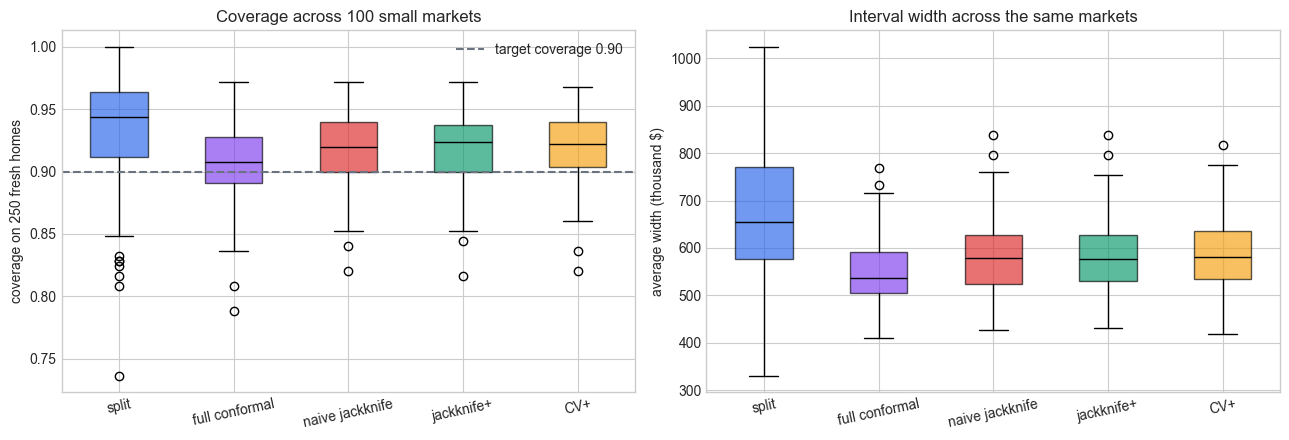

In [12]:
colors = {"split": BLUE, "full conformal": PURPLE, "naive jackknife": RED,
          "jackknife+": GREEN, "CV+": AMBER}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, data, title, ylab in [
    (axes[0], cov, "Coverage across 100 small markets", "coverage on 250 fresh homes"),
    (axes[1], wid, "Interval width across the same markets", "average width (thousand $)"),
]:
    box = ax.boxplot([data[m] for m in methods], tick_labels=methods, patch_artist=True,
                     medianprops=dict(color="black"))
    for patch, m in zip(box["boxes"], methods):
        patch.set_facecolor(colors[m])
        patch.set_alpha(0.65)
    ax.set_title(title)
    ax.set_ylabel(ylab)
    ax.tick_params(axis="x", rotation=12)
axes[0].axhline(0.90, color=GRAY, ls="--", lw=1.5, label="target coverage 0.90")
axes[0].legend()
plt.tight_layout()
plt.show()

The left panel is the lottery drawn five ways: split's blue box is visibly taller than
everything else, with stragglers dangling below 0.85 and one market all the way down at
0.736 — real markets where the desk would have quietly shipped an under-covering product. The all-data methods sit in
tight boxes straddling the low 0.90s, and full conformal hugs the target line closest. The
right panel is the same ranking in dollars: split's widths are both higher *and* more
scattered — remember, each split market also drew a random threshold — while the pooled
methods produce widths so stable the boxes look pinched. The table's last column priced
that stability: split's widths swing with a standard deviation of $151k from market to
market; jackknife+'s swing by $75k around a lower average. For the desk that is the
difference between quoting a product and quoting a coin flip made in preprocessing.

## 8. Choosing in practice

The bake-off generalizes to a small decision table. The bands are rough — profile your own
fit times — but the logic is fixed: data-rich means split, data-poor means pooling, and the
pooling flavor follows your compute budget.

| Your situation | Reach for | Why |
|---|---|---|
| n at or above ~1,000 and one model fit is affordable | split conformal | the calibration lottery is tame at this size; one fit, microsecond predictions (notebook 02) |
| n in the low hundreds, model expensive to refit | CV+ | K fits pool all the data; near-target coverage with a real floor |
| n in the low hundreds, model cheap to refit | jackknife+ | n fits; slightly tighter than CV+ because each model sees n-1 points |
| n tiny and refits nearly free (ridge, linear smoothers) | full conformal | the exact finite-sample guarantee with every point used twice — the efficiency ceiling |

And the same table as concepts rather than situations:

| Method | Plain-English recipe | Guarantee at 90% | Common beginner mistake |
|---|---|---|---|
| split conformal | fit once, measure errors on a holdout | at least 90%, exact | plain `np.quantile(scores, 0.9)` without the (n+1) correction — worst at small n (field guide §1) |
| full conformal | every candidate answer auditions inside the refit model | at least 90%, exact | an order-sensitive trainer silently voids the symmetry the theorem needs |
| naive jackknife | LOO errors around the full-data prediction | none | believing the conformal badge because the residuals "look held out" |
| jackknife+ | LOO errors around each LOO model's own prediction | at least 80% worst case, ~90% typical | quoting the typical 90% as if it were the guaranteed floor |
| CV+ | jackknife+ with K fold models instead of n LOO models | at least 80%-style floor, ~90% typical | scoring a fold with a model that saw it — training residuals in disguise |

One trap deserves its own paragraph, because it is the *plausible-sounding* alternative to
everything above: "just run split conformal on ten different random splits and combine the
intervals." To keep validity you must run each split at level $\alpha/N$ (a Bonferroni
correction) and intersect — and Lei et al. (2018) proved the correction outweighs the
combination: the intersected band is, with probability tending to one, *wider* than a
single split. Averaging without the correction is worse: it voids the guarantee outright.
One split, sized deliberately — and if the split waste hurts, the escape hatch is CV+ or
jackknife+, which pool data with an actual theorem attached, not split-averaging, which
pools it with wishful thinking (field guide §8).

## 9. Common mistakes to avoid

1. Using `np.quantile(scores, 0.90)` instead of the corrected
   `ceil((n+1)(1-alpha))/n` quantile with `method="higher"`. The off-by-one bites hardest
   exactly where this notebook lives — at small n — and if `ceil((n+1)(1-alpha)) > n`, the
   only honest interval is infinite: assert on it, do not clip it (field guide §1).
2. Shipping the naive jackknife and calling it conformal. Held-out-looking residuals are
   not a guarantee; the method fails silently precisely when the model is fragile
   (section 4's crater: 0.539 mean coverage on a 90% promise).
3. Running full conformal with an order-sensitive training procedure — non-shuffled SGD,
   early stopping keyed to the last rows, anything that treats point 121 specially.
   Symmetry is a hypothesis of the theorem, not a stylistic preference.
4. Building the candidate grid carelessly: too narrow and the interval is silently clipped
   at the edge (assert on edge hits, as our loops do); too coarse and every endpoint is
   quantized — our $10k rungs are already a $20k rounding on each interval.
5. Averaging or intersecting many random splits to "cancel the split noise". Provably
   wider than one split once you apply the correction validity requires (field guide §8).
6. In CV+, scoring a sale with a fold model that trained on it. One shuffled-index bug and
   your residuals are training residuals — the exact trap the calibration split exists to
   prevent (field guide §2).
7. Writing jackknife+'s *typical* 90% into a contract. The theorem signs for
   $1 - 2\alpha$; if a hard 90% floor is contractual, either calibrate at
   $\alpha/2$ or use a method with the exact guarantee.

## 10. What to say in the business review

**Strong version**

> We can give Marlow Bay honest price ranges without sacrificing any of the 120 sales.
> Using CV+ — ten refits of our standard pricing model, every sale used for both training
> and calibration — the 90%-target intervals covered 93.1% of a 2,000-home backtest at an
> average width of $695k. The alternative we rejected, a single 80/40 split, produced
> intervals averaging $775k, and when we replayed that split 200 times its realized
> coverage swung from 79.8% to 99.0% depending on which 40 homes landed in calibration.
> Ten model fits bought us tighter ranges and removed a coin flip from the product. A
> plain ridge model with jackknife+ gave even tighter ranges ($530k); whether we prefer it
> to boosting in a market this small is a modeling decision the width numbers now make
> visible.

**Weak version**

> We used the advanced no-split method, so the intervals are exact and every individual
> offer has a 90% chance of being right. With only 120 sales there is nothing more to
> gain from collecting data.

The weak version overclaims three times in two sentences: the coverage guarantee is
marginal — a batting average over homes and datasets, not a per-offer probability
(notebook 03); jackknife+ and CV+ carry a $1-2\alpha$ worst-case floor, not an "exact"
dial; and more sales would tighten everything — pooling methods stretch scarce data, they
do not repeal it.

### The one-line summary

Split conformal buys the guarantee by spending data; full conformal buys it by spending
refits; jackknife+ and CV+ negotiate between the two with a slightly softer theorem. At
n = 120 the split pays twice — wide intervals and a lottery-ticket threshold — while ten
refits of the same model bought the desk tighter, steadier intervals with every sale
working double shifts.

When data is scarce, pay with compute; when compute is scarce, pay with data — the
guarantee takes either currency.